In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
mfdata_DIR='/home/arif/Desktop/Python Lab/Data 09-06-18-20260211T061549Z-1-001/Data 09-06-18/gpm*'
df=xr.open_mfdataset(mfdata_DIR,parallel=True, engine='netcdf4')


In [4]:
df

<xarray.Dataset> Size: 17MB
Dimensions:           (time: 48, lon: 274, lat: 331)
Coordinates:
  * time              (time) datetime64[ns] 384B 2018-06-09 ... 2018-06-09T23...
  * lon               (lon) float32 1kB 68.95 69.05 69.15 ... 96.05 96.15 96.25
  * lat               (lat) float32 1kB 5.35 5.45 5.55 ... 38.15 38.25 38.35
Data variables:
    precipitationCal  (time, lon, lat) float32 17MB dask.array<chunksize=(1, 274, 239), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/06;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=6a;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR.MS.MRG.3IMERG.20180609-S00...
    history_L34RS:                          'Created by L34RS v1.4.3 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [5]:
min_lon=75.50
min_lat=26.50
max_lon=79.00
max_lat=30.00

In [6]:
df1=df.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [7]:
df1

<xarray.Dataset> Size: 236kB
Dimensions:           (time: 48, lon: 35, lat: 35)
Coordinates:
  * time              (time) datetime64[ns] 384B 2018-06-09 ... 2018-06-09T23...
  * lon               (lon) float32 140B 75.55 75.65 75.75 ... 78.75 78.85 78.95
  * lat               (lat) float32 140B 26.55 26.65 26.75 ... 29.75 29.85 29.95
Data variables:
    precipitationCal  (time, lon, lat) float32 235kB dask.array<chunksize=(1, 35, 27), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/06;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=6a;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR.MS.MRG.3IMERG.20180609-S00...
    history_L34RS:                          'Created by L34RS v1.4.3 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [8]:
pricp=df1.precipitationCal

In [9]:
pricp_avg=pricp.mean(dim=['lat','lon'])

In [10]:
pricp_avg

<xarray.DataArray 'precipitationCal' (time: 48)> Size: 192B
dask.array<mean_agg-aggregate, shape=(48,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 384B 2018-06-09 ... 2018-06-09T23:30:00

In [11]:
pricp_avg1=[]
for i in range(0,48,2):
    pricp_avg1.append(pricp_avg[i]+pricp_avg[i+1])

In [12]:
pricp_avg1=np.asarray(pricp_avg1)

In [13]:
pricp_avg1

array([0.14684747, 0.2973492 , 0.5533091 , 0.7506933 , 1.1234461 ,
       1.5484076 , 0.9371035 , 0.3368441 , 1.2645279 , 3.3742864 ,
       4.2275763 , 3.8286815 , 2.7075999 , 3.4088755 , 3.718161  ,
       2.9711387 , 1.3064134 , 1.2179775 , 0.8914554 , 0.32661408,
       0.07503285, 0.08329958, 0.06080607, 0.10648043], dtype=float32)

In [14]:
time=np.arange(0,24)
time.shape
print(time)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


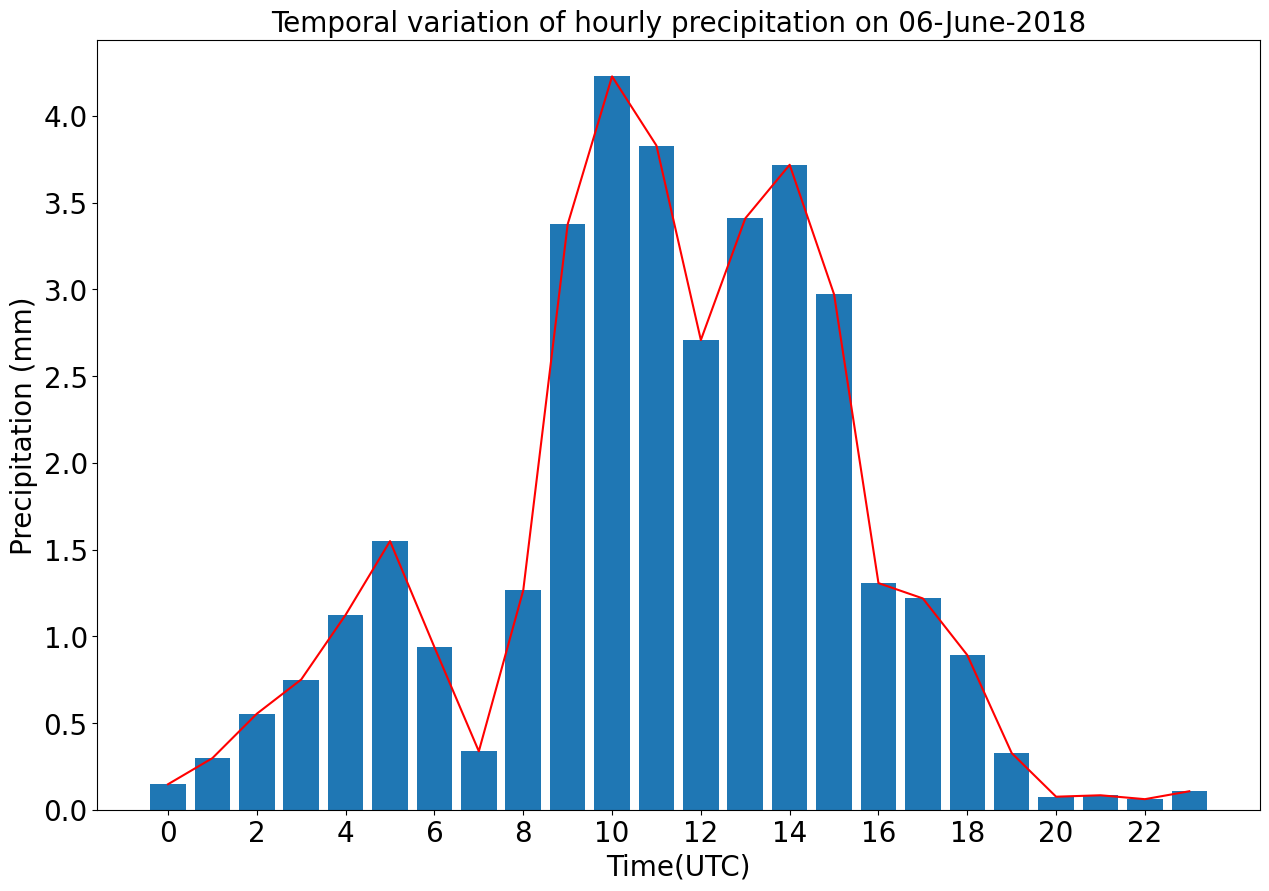

In [18]:
plt.figure(figsize=(15,10))
plt.bar(time,pricp_avg1)
plt.plot(time,pricp_avg1,color="red")
plt.xticks(np.arange(0,24,step=2),fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time(UTC)',fontsize=20)
plt.ylabel('Precipitation (mm)',fontsize=20)
plt.title("Temporal variation of hourly precipitation on 06-June-2018",fontsize=20)
plt.savefig('/home/arif/Desktop/Python Lab/Temporal Variation of Hourly Rainfall.jpg',dpi=300)

